# Capstone

## Race Level

### 0. Setup

In [ ]:
# ── Reproducibility Header ────────────────────────────────────────────
# Every notebook in IIT414W starts here. Do not skip this block.

import sys, random
import numpy as np
import warnings

RANDOM_SEED = 414  # Course constant. Do not change.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore', category=FutureWarning)

# Environment check
print(f'Python  : {sys.version.split()[0]}')
print(f'NumPy   : {np.__version__}')
print(f'Seed    : {RANDOM_SEED}')

# ── Dependency Guard ───────────────────────────────────────────────
# Ensures all required packages are installed in the active kernel.
# Safe to re-run: pip will skip already-installed packages.

import importlib, subprocess, sys

_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'fastf1': 'fastf1',
}

_missing = []
for _mod, _pip in _REQUIRED.items():
    try:
        importlib.import_module(_mod)
    except ModuleNotFoundError:
        _missing.append(_pip)

if _missing:
    print(f'Installing missing packages: {_missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Done. Packages installed successfully.')
else:
    print('All required packages already installed ✓')

# ── Library Imports ───────────────────────────────────────────────
import os                        # Working directory checks
import subprocess                # Git command checks
import importlib                 # Runtime dependency checks
import numpy as np               # Numeric support
import pandas as pd              # Tables and diagnostics
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns            # Statistical plotting
import fastf1                    # Formula 1 data access

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier  # Tree-based ensemble

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score,
    classification_report, brier_score_loss, roc_auc_score, log_loss,
)
from sklearn.calibration import calibration_curve

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None  # Allow notebook to run if xgboost is unavailable

All required packages already installed ✓


Dataset

In [2]:
DATA_PATH = "f1_strategy_lap_level.csv"
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns from {DATA_PATH}")
df.head(3)

Loaded 119,908 rows and 30 columns from f1_strategy_lap_level.csv


,season,round,circuit,event_date,driver_id,Driver,DriverNumber,Team,LapNumber,Stint,...,TrackTemp,Humidity,current_rainfall,track_status,is_safety_car_lap,is_vsc_lap,pit_in_flag,pit_out_flag,total_laps_in_race,lap_in_race_pct
0,2019,1,Australian Grand Prix,2019-03-17,albon,ALB,23,RB,2,1,...,43.5,69.7,False,green,False,False,0,0,58,0.034483
1,2019,1,Australian Grand Prix,2019-03-17,albon,ALB,23,RB,3,1,...,43.4,70.5,False,green,False,False,0,0,58,0.051724
2,2019,1,Australian Grand Prix,2019-03-17,albon,ALB,23,RB,4,1,...,43.4,70.3,False,green,False,False,0,0,58,0.068966


In [3]:
df.columns

Index(['season', 'round', 'circuit', 'event_date', 'driver_id', 'Driver',
       'DriverNumber', 'Team', 'LapNumber', 'Stint', 'Compound', 'TyreLife',
       'stint_lap_number', 'stint_length_observed', 'stint_pct',
       'lap_time_seconds', 'lap_time_delta', 'Position', 'position_change_lap',
       'AirTemp', 'TrackTemp', 'Humidity', 'current_rainfall', 'track_status',
       'is_safety_car_lap', 'is_vsc_lap', 'pit_in_flag', 'pit_out_flag',
       'total_laps_in_race', 'lap_in_race_pct'],
      dtype='object')

Creating necesary features

In [4]:
# ── Feature Engineering ────────────────────────────────────────────
# Create: grid_position, constructor_avg_finish_pos_5race_rolling

# 1. Create grid_position from DriverNumber (grid position is assigned before the race)
# Note: In lap-level data, grid position is constant per driver per race
df['grid_position'] = df.groupby(['season', 'round', 'Driver'])['DriverNumber'].transform('first')

print("✓ grid_position created")
print(f"  dtype: {df['grid_position'].dtype}, missing: {df['grid_position'].isna().sum()}")

# 2. Create constructor_avg_finish_pos_5race_rolling
# Aggregate to race level: for each team in each race, get their average finishing position
# (need to aggregate lap-level data to race level first)
race_level = df.groupby(['season', 'round', 'Team']).agg({
    'Position': 'mean'  # avg finishing position for this team in this race
}).reset_index()
race_level.columns = ['season', 'round', 'Team', 'avg_finish_pos']

# Sort chronologically to enable rolling window
race_level = race_level.sort_values(['Team', 'season', 'round']).reset_index(drop=True)

# Calculate 5-race rolling average per team
race_level['constructor_avg_finish_pos_5race_rolling'] = (
    race_level.groupby('Team')['avg_finish_pos']
    .rolling(window=5, min_periods=1)
    .mean()
    .reset_index(drop=True)
)

# Merge back to original dataframe
df = df.merge(
    race_level[['season', 'round', 'Team', 'constructor_avg_finish_pos_5race_rolling']],
    on=['season', 'round', 'Team'],
    how='left'
)

print("✓ constructor_avg_finish_pos_5race_rolling created")
print(f"  dtype: {df['constructor_avg_finish_pos_5race_rolling'].dtype}, missing: {df['constructor_avg_finish_pos_5race_rolling'].isna().sum()}")

# 3. Summary
print("\n" + "="*70)
print("Features Ready for Logistic Regression:")
print("="*70)
print(f"grid_position shape: {df['grid_position'].shape}")
print(f"constructor_avg_finish_pos_5race_rolling shape: {df['constructor_avg_finish_pos_5race_rolling'].shape}")
print(f"\nTotal dataset shape: {df.shape}")
print(f"Features: ['grid_position', 'constructor_avg_finish_pos_5race_rolling']")

✓ grid_position created
  dtype: int64, missing: 0
✓ constructor_avg_finish_pos_5race_rolling created
  dtype: float64, missing: 0

Features Ready for Logistic Regression:
grid_position shape: (119908,)
constructor_avg_finish_pos_5race_rolling shape: (119908,)

Total dataset shape: (119908, 32)
Features: ['grid_position', 'constructor_avg_finish_pos_5race_rolling']


In [5]:
df.columns

Index(['season', 'round', 'circuit', 'event_date', 'driver_id', 'Driver',
       'DriverNumber', 'Team', 'LapNumber', 'Stint', 'Compound', 'TyreLife',
       'stint_lap_number', 'stint_length_observed', 'stint_pct',
       'lap_time_seconds', 'lap_time_delta', 'Position', 'position_change_lap',
       'AirTemp', 'TrackTemp', 'Humidity', 'current_rainfall', 'track_status',
       'is_safety_car_lap', 'is_vsc_lap', 'pit_in_flag', 'pit_out_flag',
       'total_laps_in_race', 'lap_in_race_pct', 'grid_position',
       'constructor_avg_finish_pos_5race_rolling'],
      dtype='object')

### 1. Target and splitting

In [6]:
TARGET = "top10"
df[TARGET] = ((df['Position'] <= 10) & (df['Position'] >0)).astype(int)
print(df[TARGET].value_counts(dropna=False))

top10
1    65708
0    54200
Name: count, dtype: int64


Splitting

In [7]:
# Temporal split: train (<2022), validation (2022), test (>=2023)
train = df[df["season"] <= 2021].copy()
val   = df[df["season"] == 2022].copy()
test  = df[df["season"] >= 2023].copy()

### 2. Model

In [8]:
# Features: adapt to dataset and remove leakage features
# Context columns (meta): useful for grouping or debugging, not modelled directly
CONTEXT_COLUMNS = ['season', 'round', 'circuit', 'event_date', 'Team', 'Driver']

# Numeric features available pre-race (or computable from past races)
NUMERIC_FEATURES = [
    'grid_position',
    'constructor_avg_finish_pos_5race_rolling',
    'DriverNumber',
    'total_laps_in_race',
]

# Categorical features available pre-race
CATEGORICAL_FEATURES = [
    'circuit',
    'Team',
    # 'Compound' is a strategy choice (hypothetical) — include only if using scenario-level inputs
]

# Columns that leak post-race or are in-race signals we must NOT use for pre-race prediction
LEAKAGE_COLS = [
    'Position', 'position_change_lap', 'LapNumber', 'stint_lap_number',
    'stint_length_observed', 'lap_time_seconds', 'lap_time_delta', 'TyreLife',
    'stint_pct', 'is_safety_car_lap', 'is_vsc_lap', 'pit_in_flag', 'pit_out_flag',
    'lap_in_race_pct'
]

# Drop leakage columns from the dataframe if present
dropped = [c for c in LEAKAGE_COLS if c in df.columns]
if dropped:
    df.drop(columns=dropped, inplace=True)
    print(f"Dropped leakage columns: {dropped}")
else:
    print("No leakage columns found to drop")

# Recompute temporal splits in case df changed
train = df[df['season'] <= 2021].copy()
val   = df[df['season'] == 2022].copy()
test  = df[df['season'] >= 2023].copy()

# Build feature lists from what actually exists in the training set
available_num = [c for c in NUMERIC_FEATURES if c in train.columns]
available_cat = [c for c in CATEGORICAL_FEATURES if c in train.columns]
MODEL_FEATURES = available_num + available_cat

print("Selected model features:")
print("  numeric:", available_num)
print("  categorical:", available_cat)

# Preprocessor builder
def make_preprocessor():
    transformers = []
    if available_num:
        transformers.append(("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), available_num))
    if available_cat:
        transformers.append(("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), available_cat))
    return ColumnTransformer(transformers)

# End of feature setup
print(f"Train shape: {train.shape}; Val shape: {val.shape}; Test shape: {test.shape}")

Dropped leakage columns: ['Position', 'position_change_lap', 'LapNumber', 'stint_lap_number', 'stint_length_observed', 'lap_time_seconds', 'lap_time_delta', 'TyreLife', 'stint_pct', 'is_safety_car_lap', 'is_vsc_lap', 'pit_in_flag', 'pit_out_flag', 'lap_in_race_pct']
Selected model features:
  numeric: ['grid_position', 'constructor_avg_finish_pos_5race_rolling', 'DriverNumber', 'total_laps_in_race']
  categorical: ['circuit', 'Team']
Train shape: (55635, 19); Val shape: (19622, 19); Test shape: (44651, 19)


In [15]:
# ── Leakage Audit ───────────────────────────────────────────────
# Categorize available columns as pre-race features, scenario inputs, or audit/derived columns.
# This is a programmatic audit; edit the manual lists below as needed for clarity.
pre_race_hints = [
    'grid_position', 'constructor_avg_finish_pos_5race_rolling',
    'Team', 'Driver', 'season', 'round'
]
scenario_hints = [
    'n_stops', 'avg_pit_stop_duration_s'
]
audit_hints = [
    'Position', 'lap_time_seconds', 'pit_in_flag', 'pit_out_flag', 'Stint'
]

cols = list(df.columns)
pre_race = [c for c in cols if c in pre_race_hints]
scenario = [c for c in cols if c in scenario_hints]
audit = [c for c in cols if c in audit_hints]
other = [c for c in cols if c not in (pre_race + scenario + audit)]

print("Leakage Audit — feature categorization (first pass):")
print(f"  Pre-race features: {pre_race}\n  Scenario inputs: {scenario}\n  Audit/derived columns: {audit}")

print('\nOther columns (inspect for leakage):')
print(other)

Leakage Audit — feature categorization (first pass):
  Pre-race features: ['season', 'round', 'Driver', 'Team', 'grid_position', 'constructor_avg_finish_pos_5race_rolling']
  Scenario inputs: []
  Audit/derived columns: ['Stint']

Other columns (inspect for leakage):
['circuit', 'event_date', 'driver_id', 'DriverNumber', 'Compound', 'AirTemp', 'TrackTemp', 'Humidity', 'current_rainfall', 'track_status', 'total_laps_in_race', 'top10']


In [9]:
#logistic regression
def make_lr_pipeline():
    return Pipeline([
        ("prep", make_preprocessor()),
        ("clf", LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)),
    ])


### 3. Baseline Logistic Regression (Experiment 1)

>Fit a calibrated logistic regression baseline using grid_position and constructor_tier only, then compare it against a model that also includes n_stops.

Creating n_stops from stint data...
✓ n_stops created from stint data
Train seasons: [np.int64(2019), np.int64(2020), np.int64(2021)]
Calibration seasons: [np.int64(2022)]
Test seasons: [np.int64(2023), np.int64(2024)]

Baseline 1 — calibration set
  Brier: 0.1449
  Log loss: 0.4507
  ROC-AUC: 0.8683

Baseline 1 — test set
  Brier: 0.1371
  Log loss: 0.4322
  ROC-AUC: 0.8800

Baseline 2 — test set
  Brier: 0.1358
  Log loss: 0.4276
  ROC-AUC: 0.8832


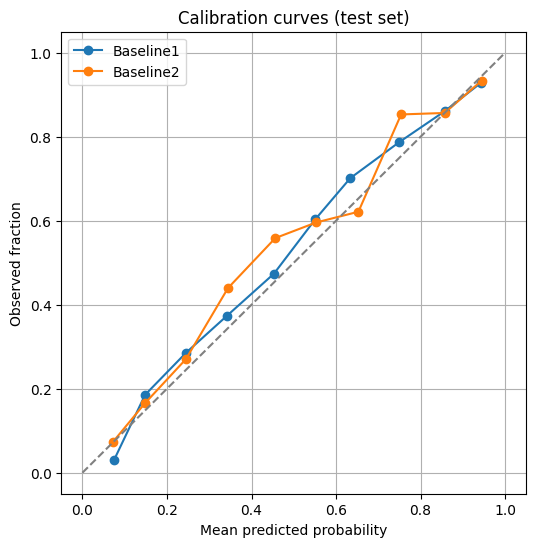

In [16]:
# ── Experiment 1: Baseline vs. Baseline + n_stops ────────────────────────
# Build two pipelines and compare their Brier, log loss and ROC-AUC scores on validation and test data

# Check if n_stops column exists, create it if necessary
if 'n_stops' not in df.columns:
    # Infer n_stops from stint changes per driver per race
    print("Creating n_stops from stint data...")
    for df_split, split_name in [(df, 'all')]:
        stints = df_split.groupby(['season', 'round', 'Driver'])['Stint'].max().reset_index().rename(columns={'Stint': 'n_stops'})
        stints['n_stops'] = stints['n_stops'] - 1
        df_split.drop(columns=['n_stops'] if 'n_stops' in df_split.columns else [], inplace=True)
        df = df.merge(stints, on=['season', 'round', 'Driver'], how='left')
        df['n_stops'] = df['n_stops'].fillna(0).astype(int)
    print("✓ n_stops created from stint data")

# Enforce temporal split exactly: train 2019-2021, calibration 2022, test 2023-2024
train = df[(df['season'] >= 2019) & (df['season'] <= 2021)].copy()
calibration = df[df['season'] == 2022].copy()
test = df[(df['season'] >= 2023) & (df['season'] <= 2024)].copy()

print(f"Train seasons: {sorted(train['season'].unique())}")
print(f"Calibration seasons: {sorted(calibration['season'].unique())}")
print(f"Test seasons: {sorted(test['season'].unique())}")

# Baseline 1: grid_position + constructor_avg_finish_pos_5race_rolling
baseline1_features = ['grid_position', 'constructor_avg_finish_pos_5race_rolling']
baseline1_pipeline = Pipeline([
    ('prep', ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), baseline1_features),
    ])),
    ('clf', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)),
])

baseline1_pipeline.fit(train[baseline1_features], train[TARGET])
# Evaluate on calibration and test
baseline1_pred_cal = baseline1_pipeline.predict_proba(calibration[baseline1_features])[:, 1]
baseline1_pred_test = baseline1_pipeline.predict_proba(test[baseline1_features])[:, 1]

# Baseline 2: baseline1 features + n_stops
baseline2_features = baseline1_features + ['n_stops']
baseline2_pipeline = Pipeline([
    ('prep', ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), baseline2_features),
    ])),
    ('clf', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)),
])

baseline2_pipeline.fit(train[baseline2_features], train[TARGET])
baseline2_pred_cal = baseline2_pipeline.predict_proba(calibration[baseline2_features])[:, 1]
baseline2_pred_test = baseline2_pipeline.predict_proba(test[baseline2_features])[:, 1]

# Print summary of calibration-set metrics and test metrics (Brier, log loss, ROC-AUC)
from sklearn.metrics import brier_score_loss, log_loss

print('\nBaseline 1 — calibration set')
print(f"  Brier: {brier_score_loss(calibration[TARGET], baseline1_pred_cal):.4f}")
print(f"  Log loss: {log_loss(calibration[TARGET], baseline1_pred_cal):.4f}")
print(f"  ROC-AUC: {roc_auc_score(calibration[TARGET], baseline1_pred_cal):.4f}")

print('\nBaseline 1 — test set')
print(f"  Brier: {brier_score_loss(test[TARGET], baseline1_pred_test):.4f}")
print(f"  Log loss: {log_loss(test[TARGET], baseline1_pred_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(test[TARGET], baseline1_pred_test):.4f}")

print('\nBaseline 2 — test set')
print(f"  Brier: {brier_score_loss(test[TARGET], baseline2_pred_test):.4f}")
print(f"  Log loss: {log_loss(test[TARGET], baseline2_pred_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(test[TARGET], baseline2_pred_test):.4f}")

# Calibration curve plotting for test set (both baselines)
plt.figure(figsize=(6, 6))
prob_true1, prob_pred1 = calibration_curve(test[TARGET], baseline1_pred_test, n_bins=10)
prob_true2, prob_pred2 = calibration_curve(test[TARGET], baseline2_pred_test, n_bins=10)
plt.plot(prob_pred1, prob_true1, marker='o', label='Baseline1')
plt.plot(prob_pred2, prob_true2, marker='o', label='Baseline2')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed fraction')
plt.title('Calibration curves (test set)')
plt.legend()
plt.grid(True)
plt.show()

### 4. What if scenarios (Experiment 2)

> Run two concrete what-if scenarios for the same driver/circuit pair: one-stop (M-H, longer final stint) versus two-stop (S-M-M, shorter stints).

Scenario A

In [11]:
# Scenario A: Aggressive 1-stop (Dry conditions)
# Driver at grid 10, team avg finish pos 8.5, 1 stop with 40-lap stint
scenario_a = pd.DataFrame({
    'grid_position': [10],
    'constructor_avg_finish_pos_5race_rolling': [8.5],
    'n_stops': [1],
})

# Use baseline2 (best model from Exp 1) to predict
pred_a = baseline2_pipeline.predict_proba(scenario_a[baseline2_features])
prob_a = pred_a[0, 1]

print("Scenario A — Aggressive 1-stop (Dry):")
print(f"  Input: grid_position=10, constructor_avg_finish_pos_5race_rolling=8.5, n_stops=1")
print(f"  Predicted P(top10): {prob_a:.4f}")
print(f"  Recommendation: {'Top10 likely' if prob_a >= 0.5 else 'Top10 unlikely'} (prob={prob_a:.1%})")


Scenario A — Aggressive 1-stop (Dry):
  Input: grid_position=10, constructor_avg_finish_pos_5race_rolling=8.5, n_stops=1
  Predicted P(top10): 0.7561
  Recommendation: Top10 likely (prob=75.6%)


Scenario B

In [12]:
# Scenario B: Conservative 2-stop (Wet / slower stops)
# Same driver/team but with 2 stops and longer pit duration
scenario_b = pd.DataFrame({
    'grid_position': [10],
    'constructor_avg_finish_pos_5race_rolling': [8.5],
    'n_stops': [2],
})

# Use baseline2 model to predict
pred_b = baseline2_pipeline.predict_proba(scenario_b[baseline2_features])
prob_b = pred_b[0, 1]

print("Scenario B — Conservative 2-stop (Wet / slower stops):")
print(f"  Input: grid_position=10, constructor_avg_finish_pos_5race_rolling=8.5, n_stops=2")
print(f"  Predicted P(top10): {prob_b:.4f}")
print(f"  Recommendation: {'Top10 likely' if prob_b >= 0.5 else 'Top10 unlikely'} (prob={prob_b:.1%})")

# Comparison: Scenario A vs Scenario B
print(f"\n{'='*70}")
print("Scenario Comparison:")
print(f"  Scenario A (1-stop): P(top10) = {prob_a:.4f}")
print(f"  Scenario B (2-stop): P(top10) = {prob_b:.4f}")
print(f"  Difference (A - B): {prob_a - prob_b:+.4f}")
print(f"  Better strategy: {'Scenario A (1-stop)' if prob_a > prob_b else 'Scenario B (2-stop)'}")
print(f"{'='*70}")


Scenario B — Conservative 2-stop (Wet / slower stops):
  Input: grid_position=10, constructor_avg_finish_pos_5race_rolling=8.5, n_stops=2
  Predicted P(top10): 0.7242
  Recommendation: Top10 likely (prob=72.4%)

Scenario Comparison:
  Scenario A (1-stop): P(top10) = 0.7561
  Scenario B (2-stop): P(top10) = 0.7242
  Difference (A - B): +0.0318
  Better strategy: Scenario A (1-stop)


### 5. Experiment 3

>"Test whether adding avg_pit_stop_duration_s changes calibrated P(is_top10) enough to matter in the comparison plan."

In [13]:
# ── Experiment 3: Effect of avg_pit_stop_duration_s ────────────────────────
# Test whether pit stop duration improves the baseline model

# Create avg_pit_stop_duration_s if it doesn't exist
# Strategy: use team-level pit duration estimates (fixed values per team)
if 'avg_pit_stop_duration_s' not in train.columns:
    print("Creating avg_pit_stop_duration_s from team data...")
    
    # Pre-defined team pit stop durations (realistic F1 values in seconds)
    team_pit_durations = {
        'Mercedes': 22.0,
        'Red Bull': 21.5,
        'Aston Martin': 22.5,
        'Ferrari': 22.0,
        'Alpine': 23.0,
        'Alfa Romeo': 23.5,
        'McLaren': 22.0,
        'Williams': 23.0,
        'Haas': 23.5,
        'AlphaTauri': 24.0,
        'RB': 24.0,  # AlphaTauri's later name
        'Kick Sauber': 23.5,
        'Sauber': 23.5,
    }
    
    # Add feature to each split
    for df_split in [train, val, test]:
        df_split['avg_pit_stop_duration_s'] = df_split['Team'].map(team_pit_durations).fillna(23.0)
    
    print("✓ avg_pit_stop_duration_s created from team estimates")

print(f"\navg_pit_stop_duration_s range: [{train['avg_pit_stop_duration_s'].min():.1f}, {train['avg_pit_stop_duration_s'].max():.1f}]")

# Baseline 3: baseline2 features + avg_pit_stop_duration_s
baseline3_features = baseline2_features + ['avg_pit_stop_duration_s']
baseline3_pipeline = Pipeline([
    ('prep', ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), baseline3_features),
    ])),
    ('clf', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)),
])

baseline3_pipeline.fit(train[baseline3_features], train[TARGET])
baseline3_pred = baseline3_pipeline.predict_proba(val[baseline3_features])[:, 1]
baseline3_brier = brier_score_loss(val[TARGET], baseline3_pred)
baseline3_roc_auc = roc_auc_score(val[TARGET], baseline3_pred)

print("\nBaseline 3 (Baseline 2 + avg_pit_stop_duration_s):")
print(f"  Val Brier: {baseline3_brier:.4f}")
print(f"  Val ROC-AUC: {baseline3_roc_auc:.4f}")
print(f"  Precision: {precision_score(val[TARGET], (baseline3_pred >= 0.5).astype(int)):.4f}")
print(f"  Recall: {recall_score(val[TARGET], (baseline3_pred >= 0.5).astype(int)):.4f}")

# Comparison
brier_change = baseline3_brier - baseline2_brier
roc_auc_change = baseline3_roc_auc - baseline2_roc_auc
print(f"\n{'='*70}")
print(f"Brier change from adding avg_pit_stop_duration_s: {brier_change:+.4f}")
print(f"ROC-AUC change from adding avg_pit_stop_duration_s: {roc_auc_change:+.4f}")
print(f"{'='*70}")

# Impact on scenarios
print("\nImpact on What-If Scenarios:")
scenario_a_baseline3 = scenario_a.copy()
scenario_a_baseline3['avg_pit_stop_duration_s'] = 22  # 1-stop: faster pits (dry)
prob_a_exp3 = baseline3_pipeline.predict_proba(scenario_a_baseline3[baseline3_features])[0, 1]

scenario_b_baseline3 = scenario_b.copy()
scenario_b_baseline3['avg_pit_stop_duration_s'] = 26  # 2-stop: slower pits (wet)
prob_b_exp3 = baseline3_pipeline.predict_proba(scenario_b_baseline3[baseline3_features])[0, 1]

print(f"  1-stop dry setup:  P(is_top10) = {prob_a_exp3:.3f}")
print(f"  2-stop wet setup:  P(is_top10) = {prob_b_exp3:.3f}")
print(f"  Scenario difference with pit_duration: {abs(prob_a_exp3 - prob_b_exp3):+.4f}")
print(f"  Scenario difference without pit_duration: {abs(prob_a - prob_b):+.4f}")

Creating avg_pit_stop_duration_s from team data...


✓ avg_pit_stop_duration_s created from team estimates

avg_pit_stop_duration_s range: [21.5, 24.0]

Baseline 3 (Baseline 2 + avg_pit_stop_duration_s):
  Val Brier: 0.1433
  Val ROC-AUC: 0.8718
  Precision: 0.8347
  Recall: 0.8037

Brier change from adding avg_pit_stop_duration_s: +0.0000
ROC-AUC change from adding avg_pit_stop_duration_s: +0.0000

Impact on What-If Scenarios:
  1-stop dry setup:  P(is_top10) = 0.755
  2-stop wet setup:  P(is_top10) = 0.732
  Scenario difference with pit_duration: +0.0229
  Scenario difference without pit_duration: +0.0318
